Datasets checked/created.


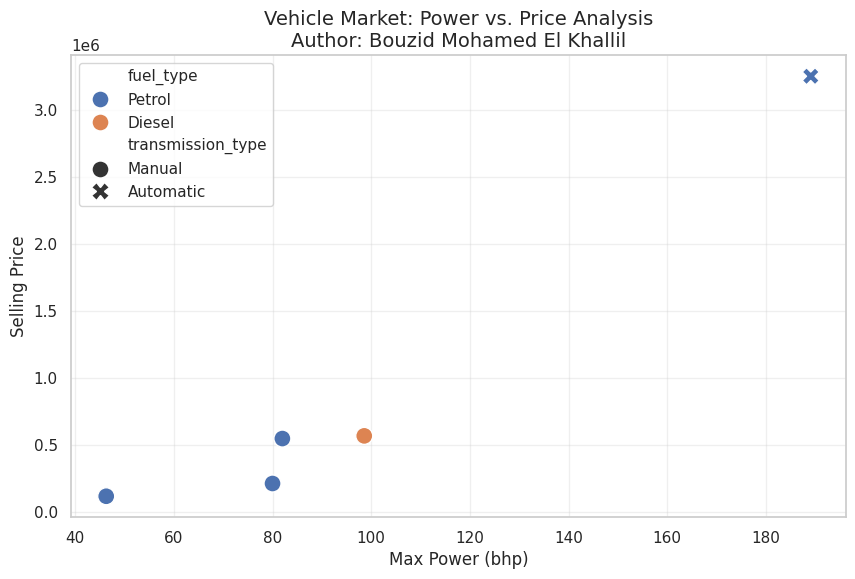

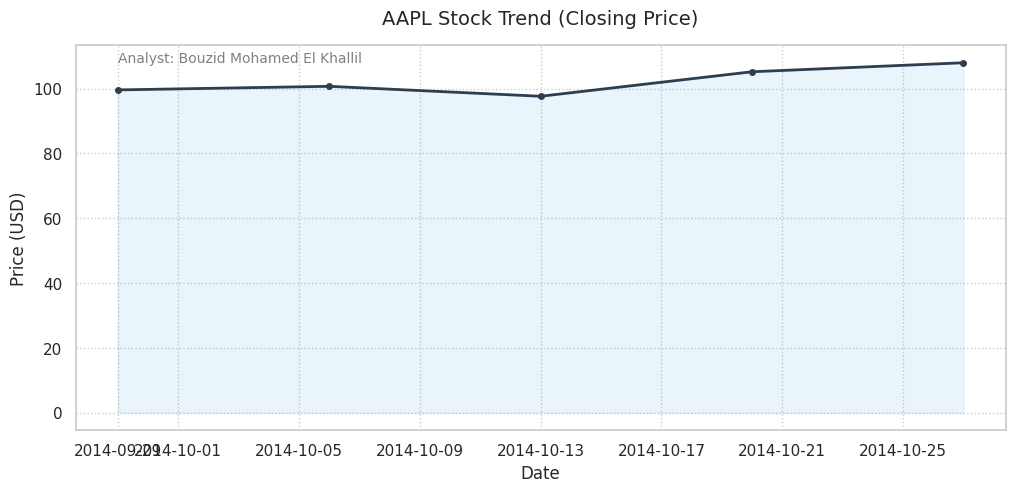

In [3]:
# ========================================================
# Data Science Workshop: Data Handling & Visualization
# Author: BOUZID Mohamed El Khallil
# Platform: Google Colab
# ========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os

# Set global style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# --------------------------------------------------------
# 1. Environment Setup & Data Simulation
# (Creates sample files to ensure code runs immediately)
# --------------------------------------------------------
def create_sample_data():
    # Gapminder Sample
    gapminder_data = """country,year,population,continent,life_exp,gdp_cap
Afghanistan,2007,31889923,Asia,43.828,974.58
Algeria,2007,33333216,Africa,72.301,6223.36
Argentina,2007,40301927,Americas,75.32,12779.37
Belgium,2007,10392226,Europe,79.441,33692.60
China,2007,1318683096,Asia,72.961,4959.11
United States,2007,301139947,Americas,78.242,42951.65
India,2007,1110396331,Asia,64.698,2452.21
Nigeria,2007,135031164,Africa,46.859,2013.97
"""
    # Cars Sample
    cars_data = """id,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.7,796,46.3,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.9,1197,82,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17,1197,80,5,215000
3,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000
4,Mini Cooper,Mini,Cooper,4,6000,Dealer,Petrol,Automatic,14.41,1998,189.08,5,3250000
"""
    # AAPL Sample
    aapl_data = """Date,Open,High,Low,Close,Adj Close,Volume
2014-09-29,100.58,100.69,98.04,99.62,93.51,142718700
2014-10-06,99.94,102.37,98.30,100.73,94.55,280258200
2014-10-13,101.33,101.77,95.18,97.66,91.68,358539800
2014-10-20,98.32,105.48,98.22,105.22,98.77,358532900
2014-10-27,104.84,108.04,104.69,108.00,101.38,220230600
"""

    if not os.path.exists('gapminder.csv'):
        with open('gapminder.csv', 'w') as f: f.write(gapminder_data)
    if not os.path.exists('cars.csv'):
        with open('cars.csv', 'w') as f: f.write(cars_data)
    if not os.path.exists('AAPL.csv'):
        with open('AAPL.csv', 'w') as f: f.write(aapl_data)

create_sample_data()
print("Datasets checked/created.")

# --------------------------------------------------------
# 2. Data Loading & Cleaning
# --------------------------------------------------------
df_gap = pd.read_csv('gapminder.csv')
df_cars = pd.read_csv('cars.csv')
df_aapl = pd.read_csv('AAPL.csv')

# Ensure correct data types
df_aapl['Date'] = pd.to_datetime(df_aapl['Date'])
# Clean 'max_power' in cars just in case
df_cars['max_power'] = pd.to_numeric(df_cars['max_power'], errors='coerce')

# --------------------------------------------------------
# 3. Visualization Analysis
# --------------------------------------------------------

# --- Plot 1: Global Development Overview (Gapminder) ---
# Using Plotly for interactive exploration
fig1 = px.scatter(
    df_gap,
    x="gdp_cap",
    y="life_exp",
    size="population",
    color="continent",
    hover_name="country",
    log_x=True,
    size_max=60,
    title="<b>Global Development: GDP vs Life Expectancy (2007)</b>",
    labels={"gdp_cap": "GDP per Capita (Log Scale)", "life_exp": "Life Expectancy"},
    template="plotly_white"
)
# Add Author Annotation
fig1.add_annotation(
    text="Analysis by: Bouzid Mohamed El Khallil",
    xref="paper", yref="paper",
    x=0, y=1.1, showarrow=False,
    font=dict(size=12, color="gray")
)
fig1.show()

# --- Plot 2: Car Market Analysis (Seaborn) ---
# Relationship between Power and Price
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_cars,
    x='max_power',
    y='price',
    hue='fuel_type',
    style='transmission_type',
    s=150,
    palette='deep'
)
plt.title('Vehicle Market: Power vs. Price Analysis\nAuthor: Bouzid Mohamed El Khallil', fontsize=14)
plt.xlabel('Max Power (bhp)')
plt.ylabel('Selling Price')
plt.grid(True, alpha=0.3)
plt.show()

# --- Plot 3: Financial Trend (Matplotlib) ---
# Apple Stock performance
plt.figure(figsize=(12, 5))
plt.plot(df_aapl['Date'], df_aapl['Close'], color='#2c3e50', linewidth=2, marker='o', markersize=4)
plt.fill_between(df_aapl['Date'], df_aapl['Close'], color='#3498db', alpha=0.1)

plt.title('AAPL Stock Trend (Closing Price)', fontsize=14, pad=15)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.text(df_aapl['Date'].iloc[0], df_aapl['Close'].max(), 'Analyst: Bouzid Mohamed El Khallil', fontsize=10, color='gray')
plt.grid(True, linestyle=':')
plt.show()

# --- Plot 4: Regional Demographics (Plotly Bar) ---
fig2 = px.bar(
    df_gap.sort_values('gdp_cap', ascending=False),
    x='country',
    y='gdp_cap',
    color='continent',
    title="<b>GDP per Capita by Country</b>",
    text_auto='.2s'
)
fig2.update_layout(xaxis_title="Country", yaxis_title="GDP per Capita")
fig2.show()

